# Jan_9th_Advertising_Linear Regression 

In [1]:
#Problem statement:- To find the effect of different type of Advertisement on Sales  

In [2]:
# import the basic library
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [3]:
os.getcwd()

'C:\\Users\\User\\Desktop\\Batch Dec12th Stats ML\\Linear Regression\\Advertising Linear Regression'

In [4]:
df=pd.read_csv("Advertising.csv")#reading dataset

In [5]:
df.head(20)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,450.0,17.5,69.2,22.1
1,2,44.5,18.5,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,NaN,18.9,58.5,18.5
4,5,180.8,15.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6


In [6]:
# It seems to be a Regression Problem as the Dependent Variable SALES is a contineous data.

In [7]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,197.000000,197.000000,200.000000,200.000000
mean,100.500000,149.696954,22.993401,30.750000,14.022500
std,57.879185,90.235859,14.665662,22.179668,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,73.400000,10.100000,12.750000,10.375000
50%,100.500000,149.800000,21.700000,25.750000,12.900000
75%,150.250000,220.300000,35.600000,45.100000,17.400000
max,200.000000,450.000000,49.600000,114.000000,27.000000


In [8]:
df.shape

(200, 5)

In [9]:
# Drop the insignificant column

In [10]:
df1=df.drop(["Unnamed: 0"],axis=1)

In [11]:
df1.head()

,TV,Radio,Newspaper,Sales
0,450.0,17.5,69.2,22.1
1,44.5,18.5,45.1,10.4
2,17.2,45.9,69.3,9.3
3,NaN,18.9,58.5,18.5
4,180.8,15.8,58.4,12.9


In [12]:
# to find the information of dataset
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         197 non-null    float64
 1   Radio      197 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [13]:
# all are numeric values float type



In [14]:
#To check the normal distribution status of data.

In [15]:
df1.skew()

TV           0.143365
Radio        0.137004
Newspaper    0.937312
Sales        0.407571
dtype: float64

In [16]:
df1.kurtosis()

TV          -0.618442
Radio       -1.183558
Newspaper    0.715567
Sales       -0.408869
dtype: float64

In [17]:
# skewness and kurtosis range -3 to +3 , it as APPROXIMATELY normally distributed.

In [18]:
# DATA PROCESSING STEP
#(1) MISSING DATA 

In [19]:
#calculate the percentage of missing value 
df1.isnull().sum()/len(df1)*100

TV           1.5
Radio        1.5
Newspaper    0.0
Sales        0.0
dtype: float64

In [20]:
df1.isnull().sum()

TV           3
Radio        3
Newspaper    0
Sales        0
dtype: int64

In [21]:
#there is missing value in TV and Radio Column

In [22]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         197 non-null    float64
 1   Radio      197 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [23]:
#df.dropna(inplace=True)  # will drop all rows with NaN in any column, but this approach is not good.

In [24]:
# checking outlier , outlier is very significant part in REGRESSION model.

<AxesSubplot:>

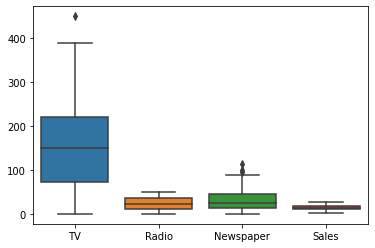

In [25]:
sns.boxplot(data=df1)

In [26]:
# handling missing value :- mean, mode, median approach

In [27]:
df1["TV"]=df1["TV"].fillna(df1["TV"].median())## Median approach because it has outliers

In [28]:
df1["Radio"]=df1["Radio"].fillna(df1["Radio"].mean())## Mean approach

In [29]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


<AxesSubplot:>

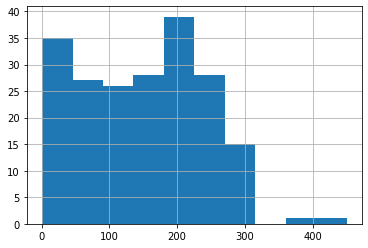

In [30]:
df1['TV'].hist()

array([[<AxesSubplot:title={'center':'TV'}>,
        <AxesSubplot:title={'center':'Radio'}>],
       [<AxesSubplot:title={'center':'Newspaper'}>,
        <AxesSubplot:title={'center':'Sales'}>]], dtype=object)

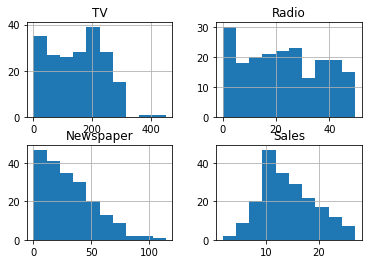

In [31]:
df1.hist()

<AxesSubplot:title={'center':'Original Data: NOT Much linear'}, ylabel='Density'>

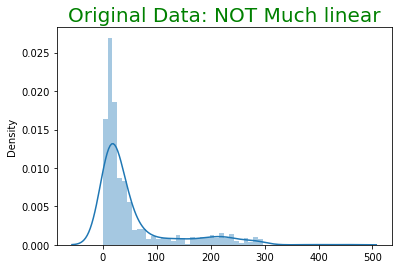

In [32]:
import matplotlib.pyplot as plt
plt.title(label="Original Data: NOT Much linear",
          fontsize=20,
          color="green")
  
import seaborn as sns
sns.distplot((df1))

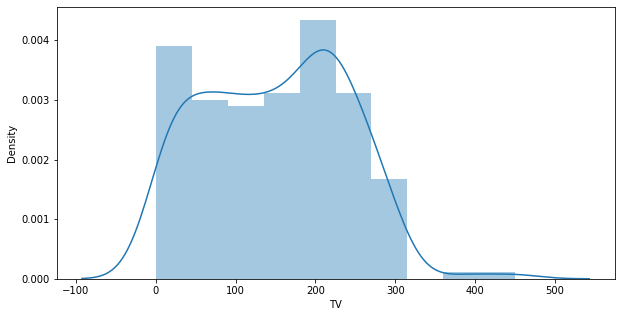

In [33]:
plt.figure(figsize=(10,5))
#plt.subplot(1,2,1)
sns.distplot(df1['TV'])
plt.show()

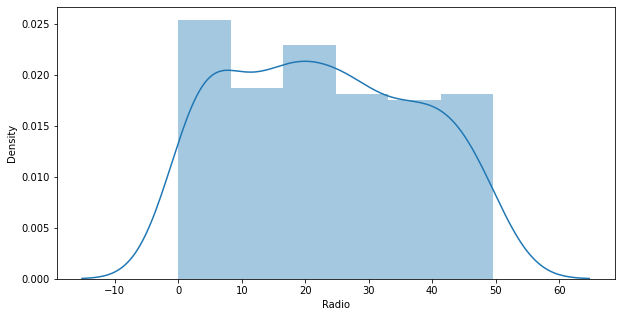

In [34]:
plt.figure(figsize=(10,5))
#plt.subplot(1,2,1)
sns.distplot(df1['Radio'])
plt.show()

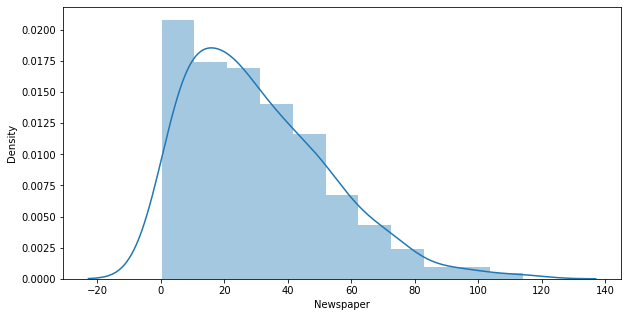

In [35]:
plt.figure(figsize=(10,5))
#plt.subplot(1,2,1)
sns.distplot(df1['Newspaper'])
plt.show()

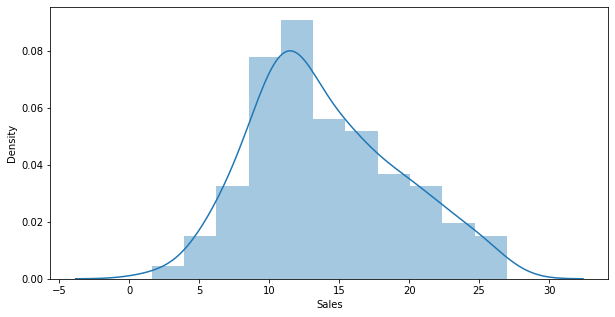

In [36]:
plt.figure(figsize=(10,5))
#plt.subplot(1,2,1)
sns.distplot(df1['Sales'])
plt.show()

In [37]:
#HELLO

NameError: name 'HELLO' is not defined

In [38]:
df1.head()

,TV,Radio,Newspaper,Sales
0,450.0,17.5,69.2,22.1
1,44.5,18.5,45.1,10.4
2,17.2,45.9,69.3,9.3
3,149.8,18.9,58.5,18.5
4,180.8,15.8,58.4,12.9


In [39]:
#create cbrt-transformed data
df1 = np.cbrt(df1)

In [40]:
df1.head()

,TV,Radio,Newspaper,Sales
0,7.663094,2.596247,4.105525,2.806278
1,3.543671,2.644786,3.559526,2.182786
2,2.581326,3.580450,4.107502,2.102944
3,5.310930,2.663712,3.881968,2.644786
4,5.654569,2.509299,3.879755,2.345290


<AxesSubplot:title={'center':'Original Data: NOT Much linear'}, ylabel='Density'>

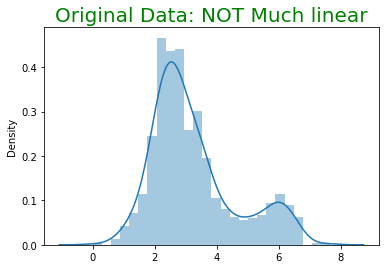

In [41]:
import matplotlib.pyplot as plt
plt.title(label="Original Data: NOT Much linear",
          fontsize=20,
          color="green")
  
import seaborn as sns
sns.distplot((df1))

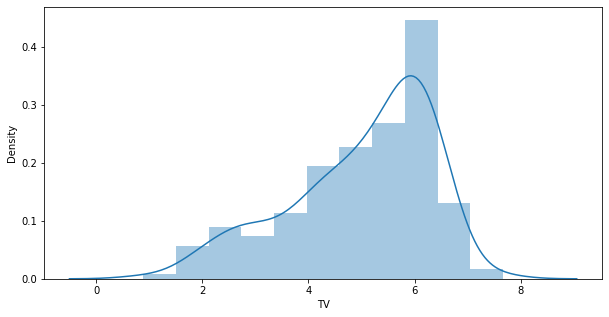

In [42]:
plt.figure(figsize=(10,5))
#plt.subplot(1,2,1)
sns.distplot(df1['TV'])
plt.show()

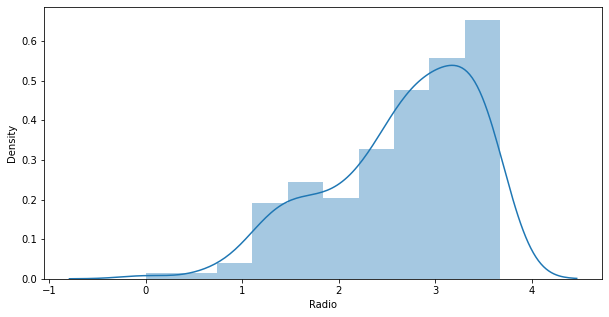

In [43]:
plt.figure(figsize=(10,5))
#plt.subplot(1,2,1)
sns.distplot(df1['Radio'])
plt.show()

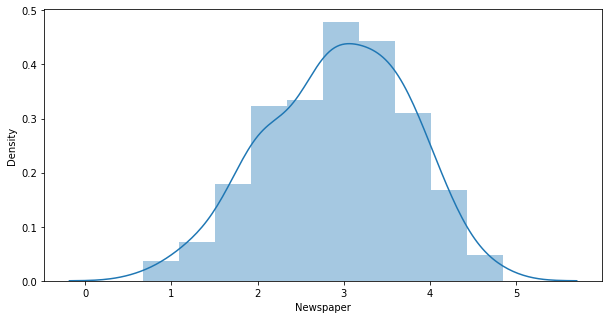

In [44]:
plt.figure(figsize=(10,5))
#plt.subplot(1,2,1)
sns.distplot(df1['Newspaper'])
plt.show()

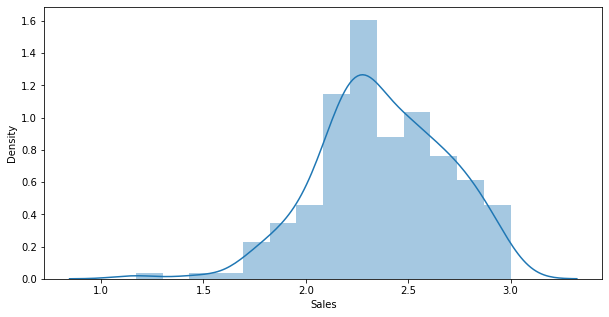

In [45]:
plt.figure(figsize=(10,5))
#plt.subplot(1,2,1)
sns.distplot(df1['Sales'])
plt.show()

In [ ]:
# checking the skewness and kurtosis

In [46]:
df1.skew()

TV          -0.804226
Radio       -0.773626
Newspaper   -0.239632
Sales       -0.326555
dtype: float64

In [47]:
df1.kurtosis()

TV          -0.119670
Radio       -0.051698
Newspaper   -0.416648
Sales        0.429271
dtype: float64

In [ ]:
# looking for outliers

<AxesSubplot:ylabel='TV'>

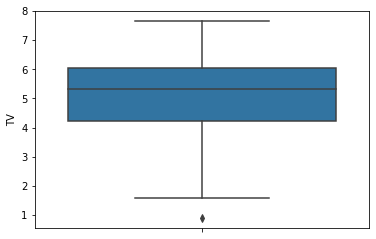

In [48]:
sns.boxplot(y="TV", data=df1)

<AxesSubplot:ylabel='Radio'>

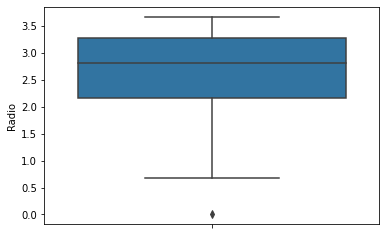

In [49]:
sns.boxplot(y="Radio", data=df1)

<AxesSubplot:ylabel='Newspaper'>

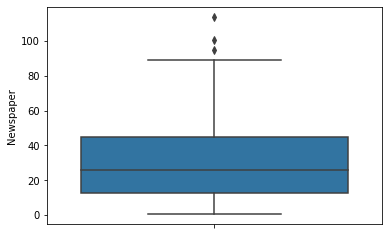

In [50]:
sns.boxplot(y="Newspaper", data=df)

In [ ]:
# Handling outliers

In [ ]:
#  FINDING IQR, Upper limit, Lower Limit

In [51]:

# here it is necessary to apply it on targeted colums , we will use numpy .

Q1_TV=df1["TV"].quantile(0.25)
print
Q3_TV=df1["TV"].quantile(0.75)
IQR_TV=Q3_TV-Q1_TV
upper_limit_TV=(Q3_TV+1.5*IQR_TV)
print("upper_limit_TV",upper_limit_TV)
lower_limit_TV=(Q1_TV-1.5*IQR_TV)
print("lower_limit_TV",lower_limit_TV)

upper_limit_TV 8.77378408536194
lower_limit_TV 1.4733572124672967


In [52]:
Q3_TV

6.036124008026449

In [53]:
# here it is necessary to apply it on targeted colums , we will use numpy .

Q1_Newspaper=df1["Newspaper"].quantile(0.25)
print
Q3_Newspaper=df1["Newspaper"].quantile(0.75)
IQR_Newspaper=Q3_Newspaper-Q1_Newspaper
upper_limit_Newspaper=(Q3_Newspaper+1.5*IQR_Newspaper)
print("upper_limit_Newspaper",upper_limit_Newspaper)
lower_limit_Newspaper=(Q1_Newspaper-1.5*IQR_Newspaper)
print("lower_limit_Newspaper",lower_limit_Newspaper)

upper_limit_Newspaper 5.394586723866761
lower_limit_Newspaper 0.5010917029445197


In [54]:
Q1_Newspaper

2.33615233579036

In [55]:
Q1_Radio=df1["Radio"].quantile(0.25)
print
Q3_Radio=df1["Radio"].quantile(0.75)
IQR_Radio=Q3_Radio-Q1_Radio
upper_limit_Radio=(Q3_Radio+1.5*IQR_Radio)
print("upper_limit_Radio",upper_limit_Radio)
lower_limit_Radio=(Q1_Radio-1.5*IQR_Radio)
print("lower_limit_Radio",lower_limit_Radio)

upper_limit_Radio 4.95422321089955
lower_limit_Radio 0.5030235433388477


In [ ]:
Q1_Radio

In [56]:
df1['TV']=np.where(df1['TV']>upper_limit_TV,upper_limit_TV,np.where(df1['TV']<lower_limit_TV,lower_limit_TV,df1['TV']))

In [57]:
df1['Newspaper']=np.where(df1['Newspaper']>upper_limit_Newspaper,upper_limit_Newspaper,np.where(df1['Newspaper']<lower_limit_Newspaper,lower_limit_Newspaper,df1['Newspaper']))

In [58]:
df1['Radio']=np.where(df1['Radio']>upper_limit_Radio,upper_limit_Radio,np.where(df1['Radio']<lower_limit_Radio,lower_limit_Radio,df1['Radio']))

In [59]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


<AxesSubplot:>

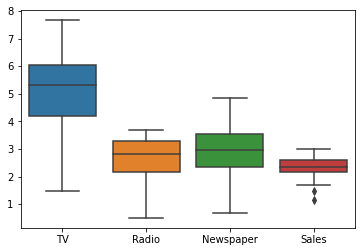

In [60]:
sns.boxplot(data=df1)

In [ ]:
# pre processing part 4 :- 

In [ ]:
#EDA-Exploratory Data Analysis
#(1)Multivariates Analysis


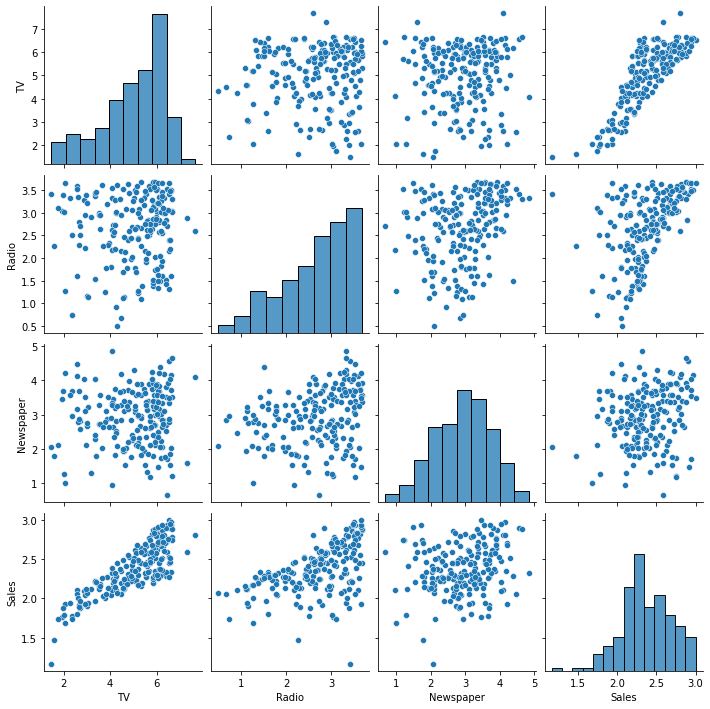

In [61]:
sns.pairplot(df1)

In [62]:
df1.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.043348,0.047251,0.829945
Radio,0.043348,1.000000,0.255902,0.500146
Newspaper,0.047251,0.255902,1.000000,0.195330
Sales,0.829945,0.500146,0.195330,1.000000


In [ ]:
# Univariate  on dependent variable price

sns.displot(df1["Sales"])

In [ ]:
df1.corr()

<AxesSubplot:>

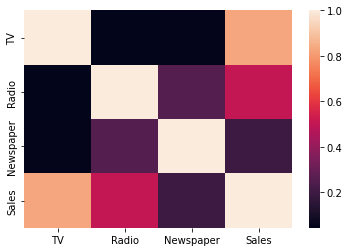

In [63]:
# if there are any two values are same , it is called Multi collinearity. than we can drop any of that equal Ind Variable.
#Same data we can plot in heatmap for more better understanding.

sns.heatmap(df1.corr())

<AxesSubplot:>

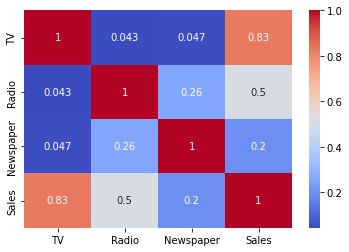

In [64]:
sns.heatmap(df1.corr(), annot=True,cmap="coolwarm")

# splitting the data into dependent and independent variable


In [65]:
df1.columns


Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [66]:
X=df1.drop(["Sales"],axis=1)

In [70]:
Y=df1[["Sales"]]

In [68]:
X.head()

,TV,Radio,Newspaper
0,7.663094,2.596247,4.105525
1,3.543671,2.644786,3.559526
2,2.581326,3.580450,4.107502
3,5.310930,2.663712,3.881968
4,5.654569,2.509299,3.879755


In [71]:
Y.head()

,Sales
0,2.806278
1,2.182786
2,2.102944
3,2.644786
4,2.345290


In [ ]:
# working on OLS algorithm regression problem

In [72]:
import statsmodels.api as sm # required for adding a constant
X=sm.add_constant(X)

In [73]:
X.head()

,const,TV,Radio,Newspaper
0,1.0,7.663094,2.596247,4.105525
1,1.0,3.543671,2.644786,3.559526
2,1.0,2.581326,3.580450,4.107502
3,1.0,5.310930,2.663712,3.881968
4,1.0,5.654569,2.509299,3.879755


In [ ]:
# splitting the data in training and testing

In [74]:
from sklearn.model_selection import train_test_split

In [84]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.75,random_state=110)

In [85]:
print(X_train.shape)
print(X_test.shape)

(150, 4)
(50, 4)


In [86]:
print(Y_train.shape)
print(Y_test.shape)

(150, 1)
(50, 1)


In [ ]:
# LINEAR REGRESSION FROM SKLEARN

In [87]:
from sklearn.linear_model import LinearRegression

In [88]:
lin_mod=LinearRegression()

In [89]:
lin_mod.fit(X_train,Y_train)

LinearRegression()

In [90]:
print(lin_mod.intercept_)

[0.89128786]


In [91]:
print(lin_mod.coef_)

[[0.         0.19324005 0.18060019 0.01143182]]


In [ ]:
#check the performance

In [92]:
Y_predict=lin_mod.predict(X_test)

In [93]:
Y_predict

array([[2.61183357],
       [2.37728421],
       [2.79880625],
       [2.69759063],
       [2.19156087],
       [2.08785593],
       [2.25593978],
       [2.64449844],
       [2.29115988],
       [2.2848252 ],
       [2.5284893 ],
       [2.3978071 ],
       [2.68160507],
       [2.58642766],
       [1.89778469],
       [2.73598426],
       [2.70437598],
       [2.72670571],
       [2.83490128],
       [2.22290475],
       [2.50963906],
       [2.13391242],
       [2.7650861 ],
       [2.58735624],
       [2.23644297],
       [2.42508827],
       [2.68005527],
       [2.12799473],
       [2.27011392],
       [2.0301626 ],
       [2.68045832],
       [2.14602533],
       [2.36482224],
       [2.84705454],
       [2.34018995],
       [2.18439336],
       [2.38039748],
       [2.58311681],
       [2.24799375],
       [2.73477809],
       [2.40471884],
       [2.43418616],
       [2.43537401],
       [2.37812968],
       [2.40649506],
       [2.49418919],
       [2.8422154 ],
       [1.513

In [94]:
pd.DataFrame(Y_predict)

,0
0,2.611834
1,2.377284
2,2.798806
3,2.697591
4,2.191561
5,2.087856
6,2.255940
7,2.644498
8,2.291160
9,2.284825


In [96]:
Y_test

,Sales
168,2.576313
197,2.339214
147,2.939530
124,2.700777
140,2.217220
65,2.102944
151,2.263702
20,2.620741
71,2.314589
86,2.289428


# REGRESSION Problem Evaluation Techniques

# """
Regression Models Evaluation metrics 
The SkLearn package in python provides various models and 
important tools for machine learning model development. 
Where it provides some regression model evaluation metrics 
in the form of functions that are callable from the sklearn package.
"""

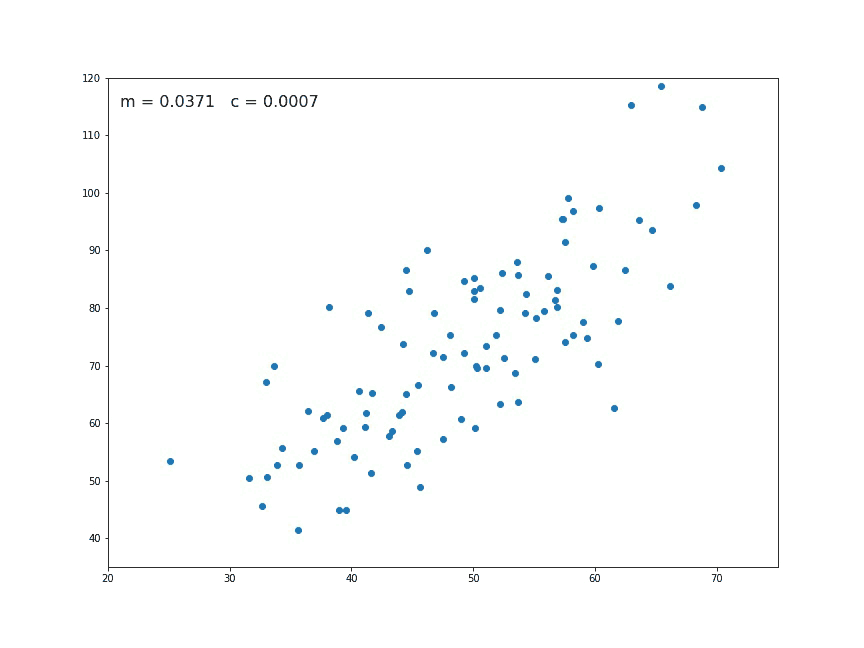

"""
Max_error

Mean Absolute Error

Mean Squared Error

Median Squared Error

R Squared
"""

In [97]:
# Max_error: maximum difference occurred between data
from sklearn.metrics import max_error
original_data = Y_test
predicted_data = Y_predict
max_error(original_data,predicted_data)

0.25092303597557297

In [98]:
#Mean Absolute Error : mean absolute Difference between the data and its average

0.056653066531536594

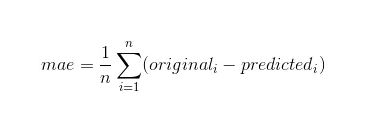

In [ ]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(Y_predict, Y_test)

In [99]:
"""
Mean Squared Error:It is as similar to the above metric wherein
Mean Squared Error we will be calculating the square 
of the difference between the predicted and the original data. 
"""

from sklearn.metrics import mean_squared_error
#mean_squared_error(original_data,predicted_data)
mean_squared_error(Y_predict, Y_test)

0.00680206577771163

In [100]:
# lets calculate root means square error 
from sklearn.metrics import mean_squared_error
lin_mod_rmse=np.sqrt(mean_squared_error(Y_predict,Y_test))
print("RMSE VALUE FOR LINEAR REGRESSION IS : ",lin_mod_rmse )

RMSE VALUE FOR LINEAR REGRESSION IS :  0.08247463717841765


###Median Absolute Error: This finds the median value of the 
absolute difference between the original and the predicted data. 
It is famous for its consistency towards robust to outliers. 
It helps us to know about the outliers present in the dataset.

In [102]:
from sklearn.metrics import median_absolute_error
median_absolute_error(Y_predict, Y_test)

0.027151858428173803

R Squared :This is the most important evaluation metric 
    in the regression evaluation where it gives us an 
    understanding of how well the data get fit towards 
    the regression line. This helps us to find the
    relationship between the independent variable 
    towards the dependent variable.

In [103]:
from sklearn.metrics import r2_score

r2_score(Y_predict, Y_test)

0.9083817849702798

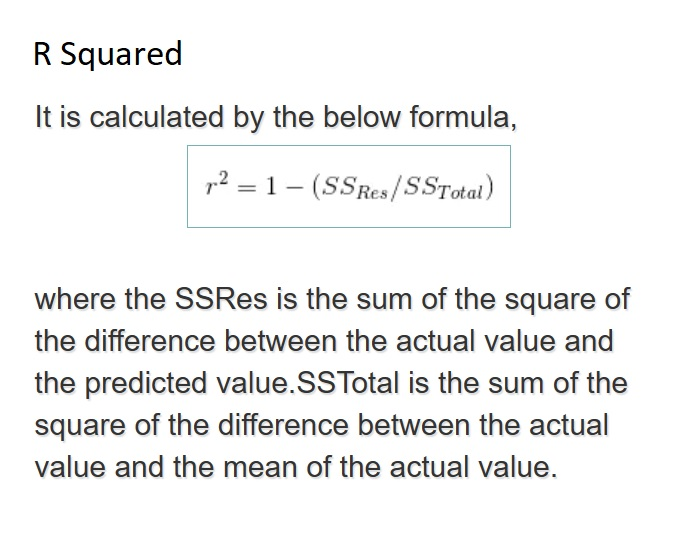

# Ordinary Least Squares(OLS)

In [124]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [125]:
VIF            = pd.DataFrame()
VIF['feature'] = X.columns
VIF['VIF']     = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
VIF

,feature,VIF
0,const,33.501508
1,TV,1.003289
2,Radio,1.071197
3,Newspaper,1.071577


In [ ]:
#OLS 
The method of Ordinary Least Squares(OLS) is most widely used model 
due to its efficiency. This model gives best approximate of true 
population regression line. The principle of OLS is to minimize the 
square of errors ( ∑ei2 ).

In [ ]:
# WE WILL DO REGRESSION MODEL EVALUATION BY USING OLS METHOD WHICH IS VERY RELIABLE .
# IT WILL GENERATE R SEQUARE VALUE AND OTHER VALUES.

In [106]:
from statsmodels.regression.linear_model import OLS
import statsmodels.regression.linear_model as smf

In [116]:
#reg_model1=smf.OLS(endog=Y_train,exog=X_train)
OLS_training = smf.OLS(Y_train, X_train)


In [117]:
OLS_training= reg_model1.fit()


In [126]:
OLS_training

In [118]:
print("Training dataset \n", OLS_training.summary())

Training dataset 
                             OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     451.5
Date:                Mon, 09 Jan 2023   Prob (F-statistic):           1.25e-73
Time:                        11:12:19   Log-Likelihood:                 133.61
No. Observations:                 150   AIC:                            -259.2
Df Residuals:                     146   BIC:                            -247.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8913      0.047 

In [119]:
print("Parameters: \n",OLS_training.params)

Parameters: 
 const        0.891288
TV           0.193240
Radio        0.180600
Newspaper    0.011432
dtype: float64


In [120]:
print("R2: ", OLS_training.rsquared)

R2:  0.9027001974605601


In [121]:
print("Standard errors: ", OLS_training.bse)

Standard errors:  const        0.046861
TV           0.005944
Radio        0.011144
Newspaper    0.010337
dtype: float64


In [123]:
print("Predicted values training data set \n: ", OLS_training.predict())

Predicted values training data set 
:  [1.84411463 2.756784   1.87870866 1.91206004 2.65070518 2.48493584
 2.62323864 2.33430715 2.18882848 2.35777137 2.5224696  2.42173422
 2.31168525 2.57791334 2.44701939 1.85475769 2.48894273 2.37763075
 2.46692308 2.65218562 2.40568593 2.53222873 2.33523282 2.03365302
 1.93273604 2.7112267  2.59430746 2.61892154 2.82533394 2.79162088
 2.51832885 2.25886496 2.35916492 2.35819626 2.39828486 2.10771865
 2.53976967 2.48150947 2.0944077  2.22733057 2.19108354 2.56140454
 2.65836785 2.43040535 2.07443201 2.03018231 2.27044793 2.33122757
 2.08368948 1.99949634 2.60030406 1.99735791 2.6288692  2.71591391
 2.55943115 2.74323824 2.41895107 2.37128289 2.3322573  2.18174335
 2.35782161 2.67863638 2.88792094 2.38848929 2.67757354 2.15888784
 1.92873257 2.28321592 2.69588347 2.14286563 2.55028854 2.10024917
 2.59825268 2.56033327 2.64291685 2.44301717 2.65090577 2.47926139
 1.83942744 2.74483822 1.90697393 2.14778997 2.63131254 2.48539477
 1.62981848 2.09730372 

# Explaination of OLS Summary report.

In [139]:
print("Training dataset \n", OLS_training.summary())

Training dataset 
                             OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     451.5
Date:                Mon, 09 Jan 2023   Prob (F-statistic):           1.25e-73
Time:                        14:46:08   Log-Likelihood:                 133.61
No. Observations:                 150   AIC:                            -259.2
Df Residuals:                     146   BIC:                            -247.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8913      0.047 

In [ ]:
"""
No. Observations: 150  # size of our sample    
Df Residuals: 146                              

#Degrees of freedom RESIDUAL = N – K
Where, N = sample size(no. of observations) and  K = number of variables + 1
DF residual =N-K
N=150
K=3+1=4
DF RESIDUAL=150-4=146
        
Df Model: 3   # DF of Model=n-1=4-1=3



#R square
# Adjusted R square
# Fstatistics:-F test tells the goodness of fit of a regression. 
The test is similar to the t-test or other tests we do for the hypothesis.
#Durbin-Watson:
"""

In [ ]:
#acceptable skewness values are between -3 and +3, 
#while acceptable kurtosis values are between -10 and +10
#both skewness and kurtosis should be used to evaluate the normality of a sample's distribution.

In [ ]:
#Constant term: The constant terms is the intercept of the 
#regression line. From regression line (eq…1) the intercept is 0.8913 . 
#Coefficient term..solpe..m1,m2,m3,m4.... as the rate of change of Y with respect to X .

In [132]:
Y_predict_OLS=OLS_training.predict(X_test)

In [133]:
Y_predict_OLS

168    2.611834
197    2.377284
147    2.798806
124    2.697591
140    2.191561
65     2.087856
151    2.255940
20     2.644498
71     2.291160
86     2.284825
41     2.528489
100    2.397807
28     2.681605
27     2.586428
119    1.897785
42     2.735984
185    2.704376
55     2.726706
198    2.834901
79     2.222905
118    2.509639
138    2.133912
30     2.765086
187    2.587356
82     2.236443
77     2.425088
53     2.680055
191    2.127995
135    2.270114
10     2.030163
92     2.680458
38     2.146025
116    2.364822
183    2.847055
115    2.340190
29     2.184393
161    2.380397
105    2.583117
6      2.247994
111    2.734778
165    2.404719
25     2.434186
43     2.435374
63     2.378130
181    2.406495
103    2.494189
11     2.842215
108    1.513581
32     2.022035
21     2.450549
dtype: float64

In [130]:
Y_test

,Sales
168,2.576313
197,2.339214
147,2.939530
124,2.700777
140,2.217220
65,2.102944
151,2.263702
20,2.620741
71,2.314589
86,2.289428


In [135]:
from sklearn.metrics import max_error as ME
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import median_absolute_error as MAE
from sklearn.metrics import r2_score

In [138]:
original_data = Y_test
predicted_data = Y_predict_OLS

E1=ME(original_data,predicted_data)
print("MAX ERROR IS : "  ,E1 )
E2=MSE(original_data,predicted_data)
print("MEAN SQUARE ERROR IS : "  ,E2 )
#ROOT MEAN SQUARE ERROR
E3=np.sqrt(mean_squared_error(original_data,predicted_data))
print("ROOT MEAN SQUARE ERROR IS : "  ,E3 )
E4=MAE(original_data,predicted_data)
print("MEAN ABSOLUTE ERROR IS : "  ,E4 )
# Accuracy r2 score
E5=r2_score(original_data,predicted_data)
print("R2 Score VALUE Accuracy IS : ",E5 )


MAX ERROR IS :  0.2509230359755752
MEAN SQUARE ERROR IS :  0.006802065777711652
ROOT MEAN SQUARE ERROR IS :  0.08247463717841778
MEAN ABSOLUTE ERROR IS :  0.027151858428172693
R2 Score VALUE Accuracy IS :  0.9113326144697713
